# Phase 1 — Proof of Concept

Ömer Faruk Merey - Middle East Technical University

GitHub: [OmerFarukMerey/remote-sensing-caption-composition](https://github.com/OmerFarukMerey/remote-sensing-caption-composition)

This notebook validates the Proof of Concept (PoC) for multimodal land cover composition prediction.

We load a single sample, run it through CLIP encoders, fuse modalities with cross-attention, and produce 7 composition percentages via a regression head.

No training is performed here, this is purely a PoC

In [1]:
import torch
import torch.nn as nn
%pip uninstall clip -y -q
%pip install git+https://github.com/openai/CLIP.git -q
import clip
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Paths — adjust if your dataset lives elsewhere
DATASET_DIR = Path("../../dataset")
IMAGES_DIR  = DATASET_DIR / "images"
MASKS_DIR   = DATASET_DIR / "masks"
CAPTIONS_CSV = DATASET_DIR / "captions.csv"

COMPOSITION_CLASSES = ["Tree", "Shrub", "Grass", "Crop", "Built-up", "Barren", "Water"]
CAPTION_COLUMNS = [
    "hybrid_gemma3-4b", "hybrid_qwen3-vl-8b",
    "text_qwen3-4b",
    "vision_gemma3-4b", "vision_qwen3-vl-8b",
]
print(DATASET_DIR)

../../dataset


---
## 1. Data Loading

Load one sample from the ARAS400k dataset: the satellite image, all 5 captions, and the ground-truth land cover composition percentages.

In [3]:
# Load captions CSV and pick the first sample
df = pd.read_csv(CAPTIONS_CSV)
sample = df.iloc[0]
filename = sample["filename"]
print(f"Sample: {filename}  |  Split: {sample['split']}")

Sample: 0073.png  |  Split: synth


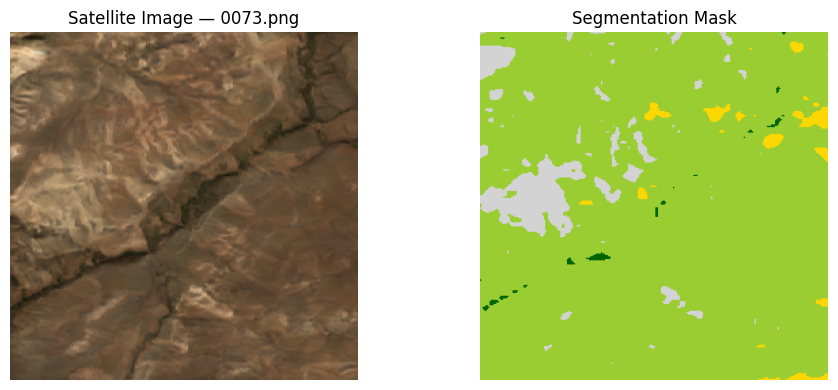

In [4]:
# Load and display the satellite image
image_path = IMAGES_DIR / filename
image = Image.open(image_path).convert("RGB")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(image)
axes[0].set_title(f"Satellite Image — {filename}")
axes[0].axis("off")

# Also show the mask if available
mask_path = MASKS_DIR / filename
if mask_path.exists():
    mask = Image.open(mask_path).convert("RGB")
    axes[1].imshow(mask)
    axes[1].set_title("Segmentation Mask")
    axes[1].axis("off")
else:
    axes[1].text(0.5, 0.5, "No mask found", ha="center", va="center")
    axes[1].axis("off")

plt.tight_layout()
plt.show()

In [5]:
# Print ground-truth composition percentages
print("Ground-Truth Composition (%):\n")
for cls in COMPOSITION_CLASSES:
    print(f"  {cls:>8s}: {sample[cls]:5.1f}%")

Ground-Truth Composition (%):

      Tree:   0.0%
     Shrub:   0.0%
     Grass:  92.0%
      Crop:   2.0%
  Built-up:   0.0%
    Barren:   6.0%
     Water:   0.0%


In [6]:
# Print all 5 captions
print("Captions:\n")
for col in CAPTION_COLUMNS:
    print(f"[{col}]")
    print(f"  {sample[col]}\n")

Captions:

[hybrid_gemma3-4b]
  The image depicts a landscape dominated by extensive grasslands (92%), with a small area of cultivated crops (2%) and sparse barren land (6%). A prominent drainage channel or gully cuts through the terrain, suggesting a significant fluvial feature within the predominantly grassy area.

[hybrid_qwen3-vl-8b]
  The scene is dominated by grassland covering 92% of the area, with sparse, fragmented crop patches and small barren zones, suggesting a largely natural, lightly managed landscape with minor agricultural activity.

[text_qwen3-4b]
  The scene is predominantly covered by grass, indicating a large area of natural or managed pastureland. Crop coverage is minimal, suggesting limited agricultural activity in the region.

[vision_gemma3-4b]
  This image depicts a rugged, arid landscape characterized by extensive rocky terrain and deeply incised gullies, likely indicative of a desert or semi-arid environment with minimal vegetation cover. The dominant land u

---
## 2. Preprocessing

Apply CLIP's standard image preprocessing (resize, center crop, normalize) and tokenize one caption using CLIP's tokenizer.

In [7]:
# Select device (I use Apple Silicon, will acquire CUDA in the other phases of the project.)
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

Device: mps


In [8]:
# Load CLIP model and preprocessing
clip_model, preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()
print(f"CLIP ViT-B/32 loaded on {device}")

CLIP ViT-B/32 loaded on mps


In [9]:
# Preprocess the image. resize to 224x224 and normalize
image_tensor = preprocess(image).unsqueeze(0).to(device)
print(f"Preprocessed image tensor shape: {image_tensor.shape}")

Preprocessed image tensor shape: torch.Size([1, 3, 224, 224])


In [10]:
# Tokenize one caption, using the first hybrid caption.
caption_text = sample["hybrid_gemma3-4b"]
text_tokens = clip.tokenize([caption_text], truncate=True).to(device)  # (1, 77)
print(f"Tokenized text shape: {text_tokens.shape}")
print(f"Caption: {caption_text[:120]}...")

Tokenized text shape: torch.Size([1, 77])
Caption: The image depicts a landscape dominated by extensive grasslands (92%), with a small area of cultivated crops (2%) and sp...


---
## 3. CLIP Encoder Forward Pass

Extractimage patch token embeddings and text token embeddings from CLIP's encoders.


In [11]:
with torch.no_grad():
    # Patchify + positional embedding
    vit = clip_model.visual
    x = vit.conv1(image_tensor.type(clip_model.dtype))
    x = x.reshape(x.shape[0], x.shape[1], -1).permute(0, 2, 1)

    # Prepend CLS token
    cls_token = vit.class_embedding.unsqueeze(0).unsqueeze(0)
    x = torch.cat([cls_token.to(x.dtype), x], dim=1)
    x = x + vit.positional_embedding.to(x.dtype)  
    x = vit.ln_pre(x)  

    # Pass through transformer blocks
    x = x.permute(1, 0, 2)  
    x = vit.transformer(x)
    x = x.permute(1, 0, 2)  
    x = vit.ln_post(x) 

    # Project all tokens to the shared embedding space (512-d)
    image_features = x @ vit.proj

    # Separate CLS token and patch tokens
    image_cls = image_features[:, 0, :]      
    image_patches = image_features[:, 1:, :]

print(f"Image CLS token shape:    {image_cls.shape}")
print(f"Image patch tokens shape: {image_patches.shape}  (7×7 grid)")

Image CLS token shape:    torch.Size([1, 512])
Image patch tokens shape: torch.Size([1, 49, 512])  (7×7 grid)


In [12]:
# Similarly, extract per-token embeddings from CLIP's text transformer.
with torch.no_grad():
    text_encoder = clip_model
    x_text = text_encoder.token_embedding(text_tokens).type(clip_model.dtype)  
    x_text = x_text + text_encoder.positional_embedding.type(clip_model.dtype) 

    # CLIP text transformer expects (seq_len, batch, dim)
    x_text = x_text.permute(1, 0, 2)  
    x_text = text_encoder.transformer(x_text)
    x_text = x_text.permute(1, 0, 2)  
    text_features = text_encoder.ln_final(x_text) 

print(f"Text token embeddings shape: {text_features.shape}")

Text token embeddings shape: torch.Size([1, 77, 512])


---
## 4. Cross-Attention Fusion

Fuse image and text representations using a single multi-head cross-attention layer.

This allows each spatial patch to attend to the most relevant words in the caption.

In [13]:
embed_dim = 512
num_heads = 8

cross_attention = nn.MultiheadAttention(
    embed_dim=embed_dim,
    num_heads=num_heads,
    batch_first=True,
).to(device)

print(f"Cross-Attention: embed_dim={embed_dim}, num_heads={num_heads}")

Cross-Attention: embed_dim=512, num_heads=8


In [14]:
fused_output, attn_weights = cross_attention(
    query=image_patches.float(),
    key=text_features.float(),
    value=text_features.float(),
)

print(f"Cross-attention output shape:  {fused_output.shape}") 
print(f"Attention weights shape:       {attn_weights.shape}")

Cross-attention output shape:  torch.Size([1, 49, 512])
Attention weights shape:       torch.Size([1, 49, 77])


---
## 5. Regression Head

Global-average-pool the fused patch representations into a single vector, then pass through a small MLP to predict composition percentages.

In [15]:
# Define the regression MLP
regression_head = nn.Sequential(
    nn.Linear(embed_dim, 256),
    nn.ReLU(),
    nn.Linear(256, len(COMPOSITION_CLASSES)),
    nn.Softmax(dim=-1),
).to(device)

print(regression_head)

Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=7, bias=True)
  (3): Softmax(dim=-1)
)


In [16]:
# Global average pooling
pooled = fused_output.mean(dim=1)
print(f"Pooled representation shape: {pooled.shape}")

# Predict composition percentages
predicted = regression_head(pooled)
predicted_pct = predicted.squeeze(0).detach().cpu().numpy() * 100

print(f"\nPredicted Composition (%) — random init, no training:\n")
for cls, pct in zip(COMPOSITION_CLASSES, predicted_pct):
    print(f"  {cls:>8s}: {pct:5.1f}%")

Pooled representation shape: torch.Size([1, 512])

Predicted Composition (%) — random init, no training:

      Tree:  16.3%
     Shrub:  14.0%
     Grass:  14.7%
      Crop:  14.9%
  Built-up:  13.4%
    Barren:  15.0%
     Water:  11.7%


---
## 6. Loss Computation

Compute Mean Squared Error (MSE) between the predicted composition percentages and the ground truth values from the dataset.

Since the model is randomly initialized (no training), we expect a high loss this cell just verifies the loss computation is wired correctly.

In [17]:
# normalize and match softmax output
gt_values = [sample[cls] for cls in COMPOSITION_CLASSES]
gt_tensor = torch.tensor(gt_values, dtype=torch.float32).unsqueeze(0).to(device) / 100.0

print(f"Ground truth (normalized): {gt_tensor.squeeze().tolist()}")
print(f"Predicted    (normalized): {predicted.squeeze().detach().tolist()}")

Ground truth (normalized): [0.0, 0.0, 0.9200000166893005, 0.019999999552965164, 0.0, 0.05999999865889549, 0.0]
Predicted    (normalized): [0.16275185346603394, 0.1399502456188202, 0.14673592150211334, 0.14850690960884094, 0.13434578478336334, 0.15035881102085114, 0.1173504889011383]


In [18]:
# Compute MSE loss
criterion = nn.MSELoss()
loss = criterion(predicted, gt_tensor)

print(f"\nMSE Loss: {loss.item():.6f}")
print(f"\n✓ Pipeline runs end-to-end. Ready for Phase 2 training experiments!")


MSE Loss: 0.100073

✓ Pipeline runs end-to-end. Ready for Phase 2 training experiments!
